In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [17]:
df = pd.read_csv("D:/LIVER DISEASE/data/Liver_data.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [18]:
print("Dataset Shape (Rows, Columns):", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape (Rows, Columns): (583, 11)

Column Names:
Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    flo

In [19]:
print("Statistical Summary of Dataset:")
df.describe()

Statistical Summary of Dataset:


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [20]:
print("Checking Missing Values:")
df.isnull().sum()

Checking Missing Values:


Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [21]:
print("Starting Data Preprocessing...")

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Convert Gender column
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Preprocessing completed successfully")
df.head()

Starting Data Preprocessing...
Preprocessing completed successfully


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Target Variable Distribution:
Dataset
1    406
2    164
Name: count, dtype: int64


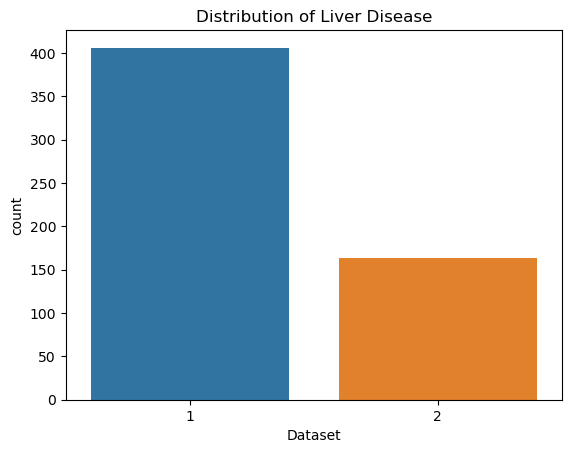

Insight: Shows number of patients with and without liver disease


In [22]:
print("Target Variable Distribution:")
print(df['Dataset'].value_counts())

sns.countplot(x='Dataset', data=df)
plt.title("Distribution of Liver Disease")
plt.show()

print("Insight: Shows number of patients with and without liver disease")

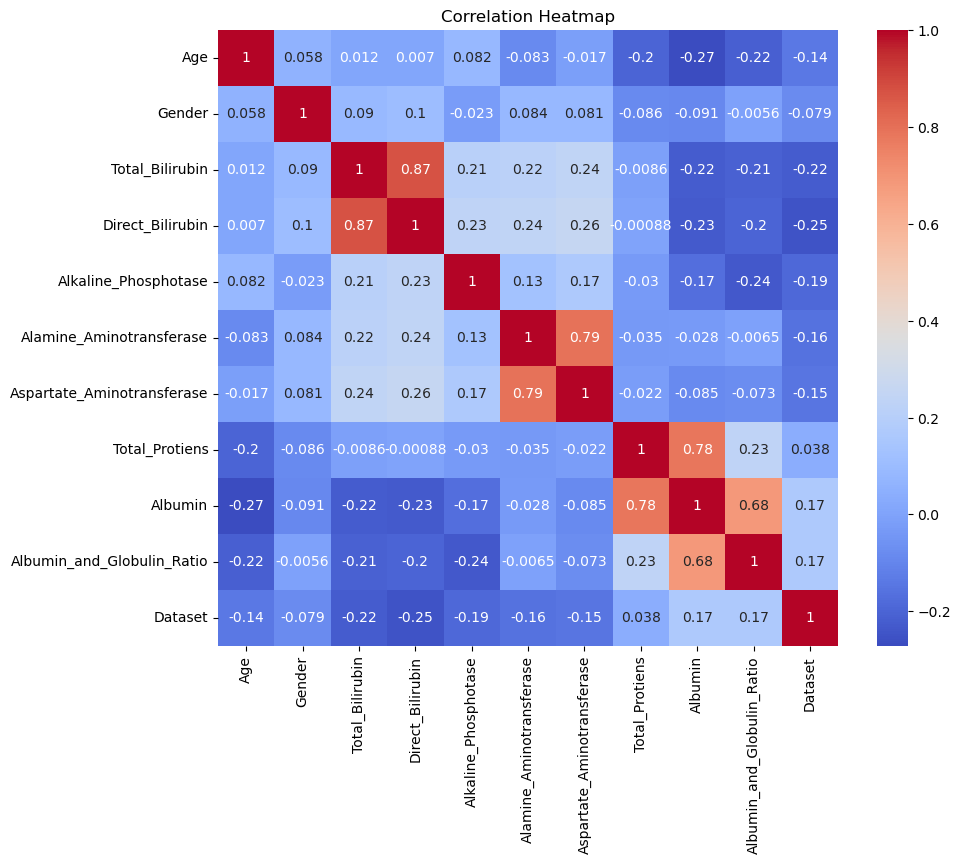

Insight: Helps identify which features strongly influence liver disease


In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Insight: Helps identify which features strongly influence liver disease")

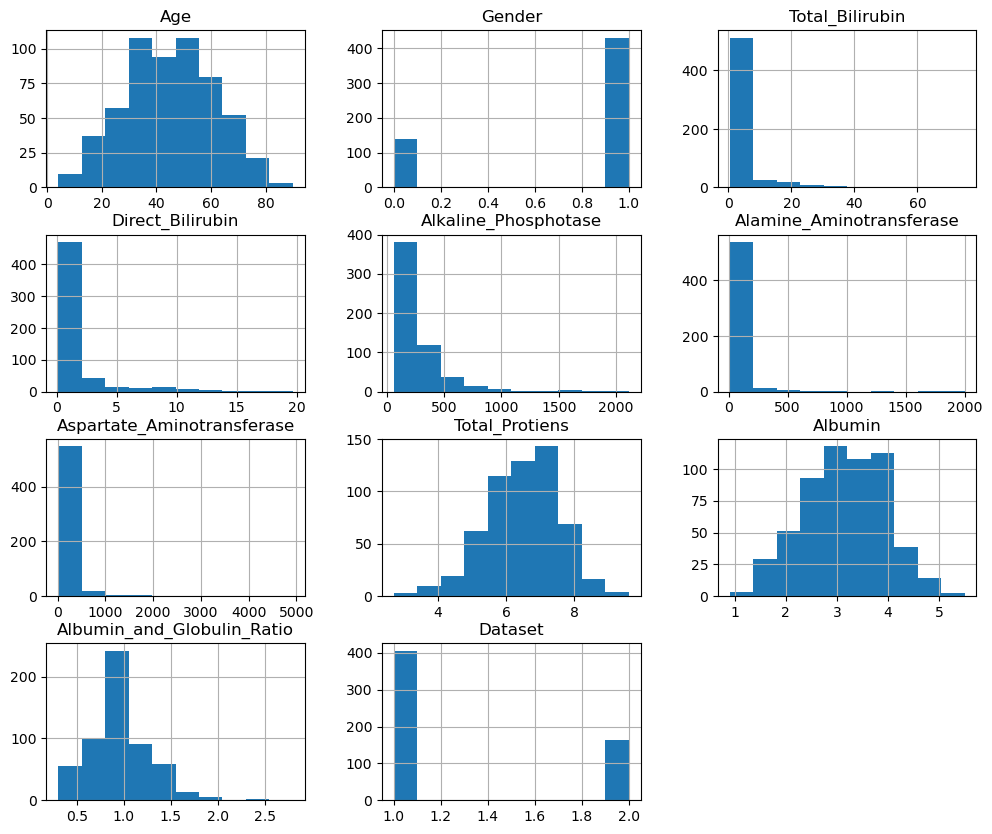

Insight: Shows distribution of each feature


In [24]:
df.hist(figsize=(12,10))
plt.show()

print("Insight: Shows distribution of each feature")

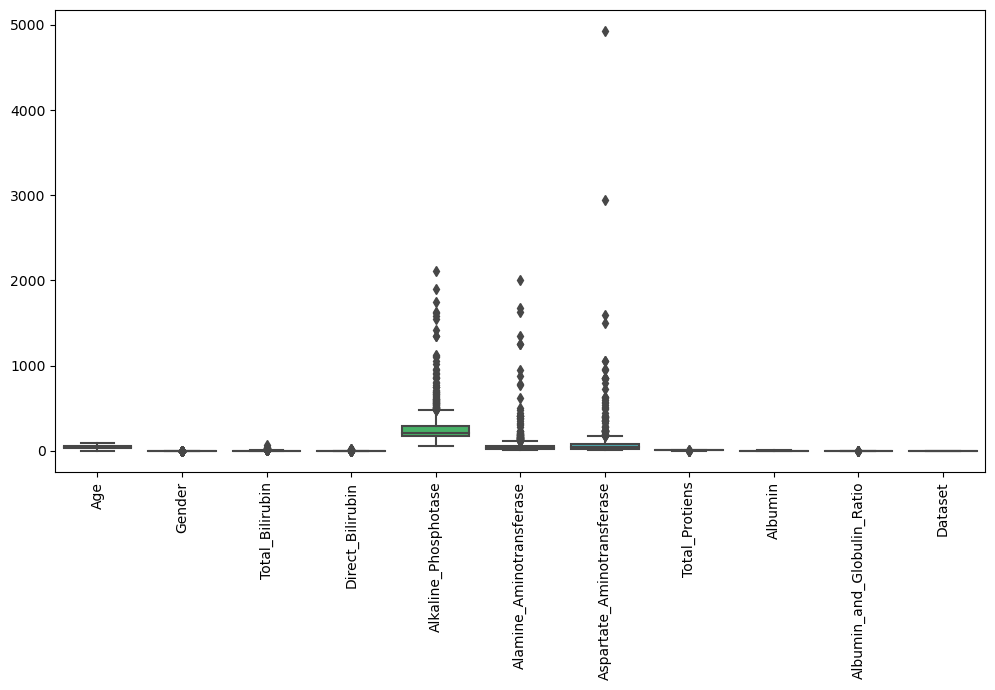

Insight: Boxplot helps detect outliers in data


In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

print("Insight: Boxplot helps detect outliers in data")

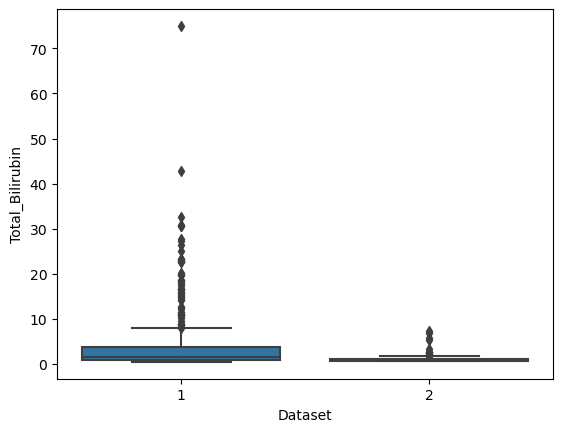

Insight: Patients with liver disease tend to have higher bilirubin levels


In [26]:
sns.boxplot(x='Dataset', y='Total_Bilirubin', data=df)
plt.show()

print("Insight: Patients with liver disease tend to have higher bilirubin levels")

c:\Users\Sanjana\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


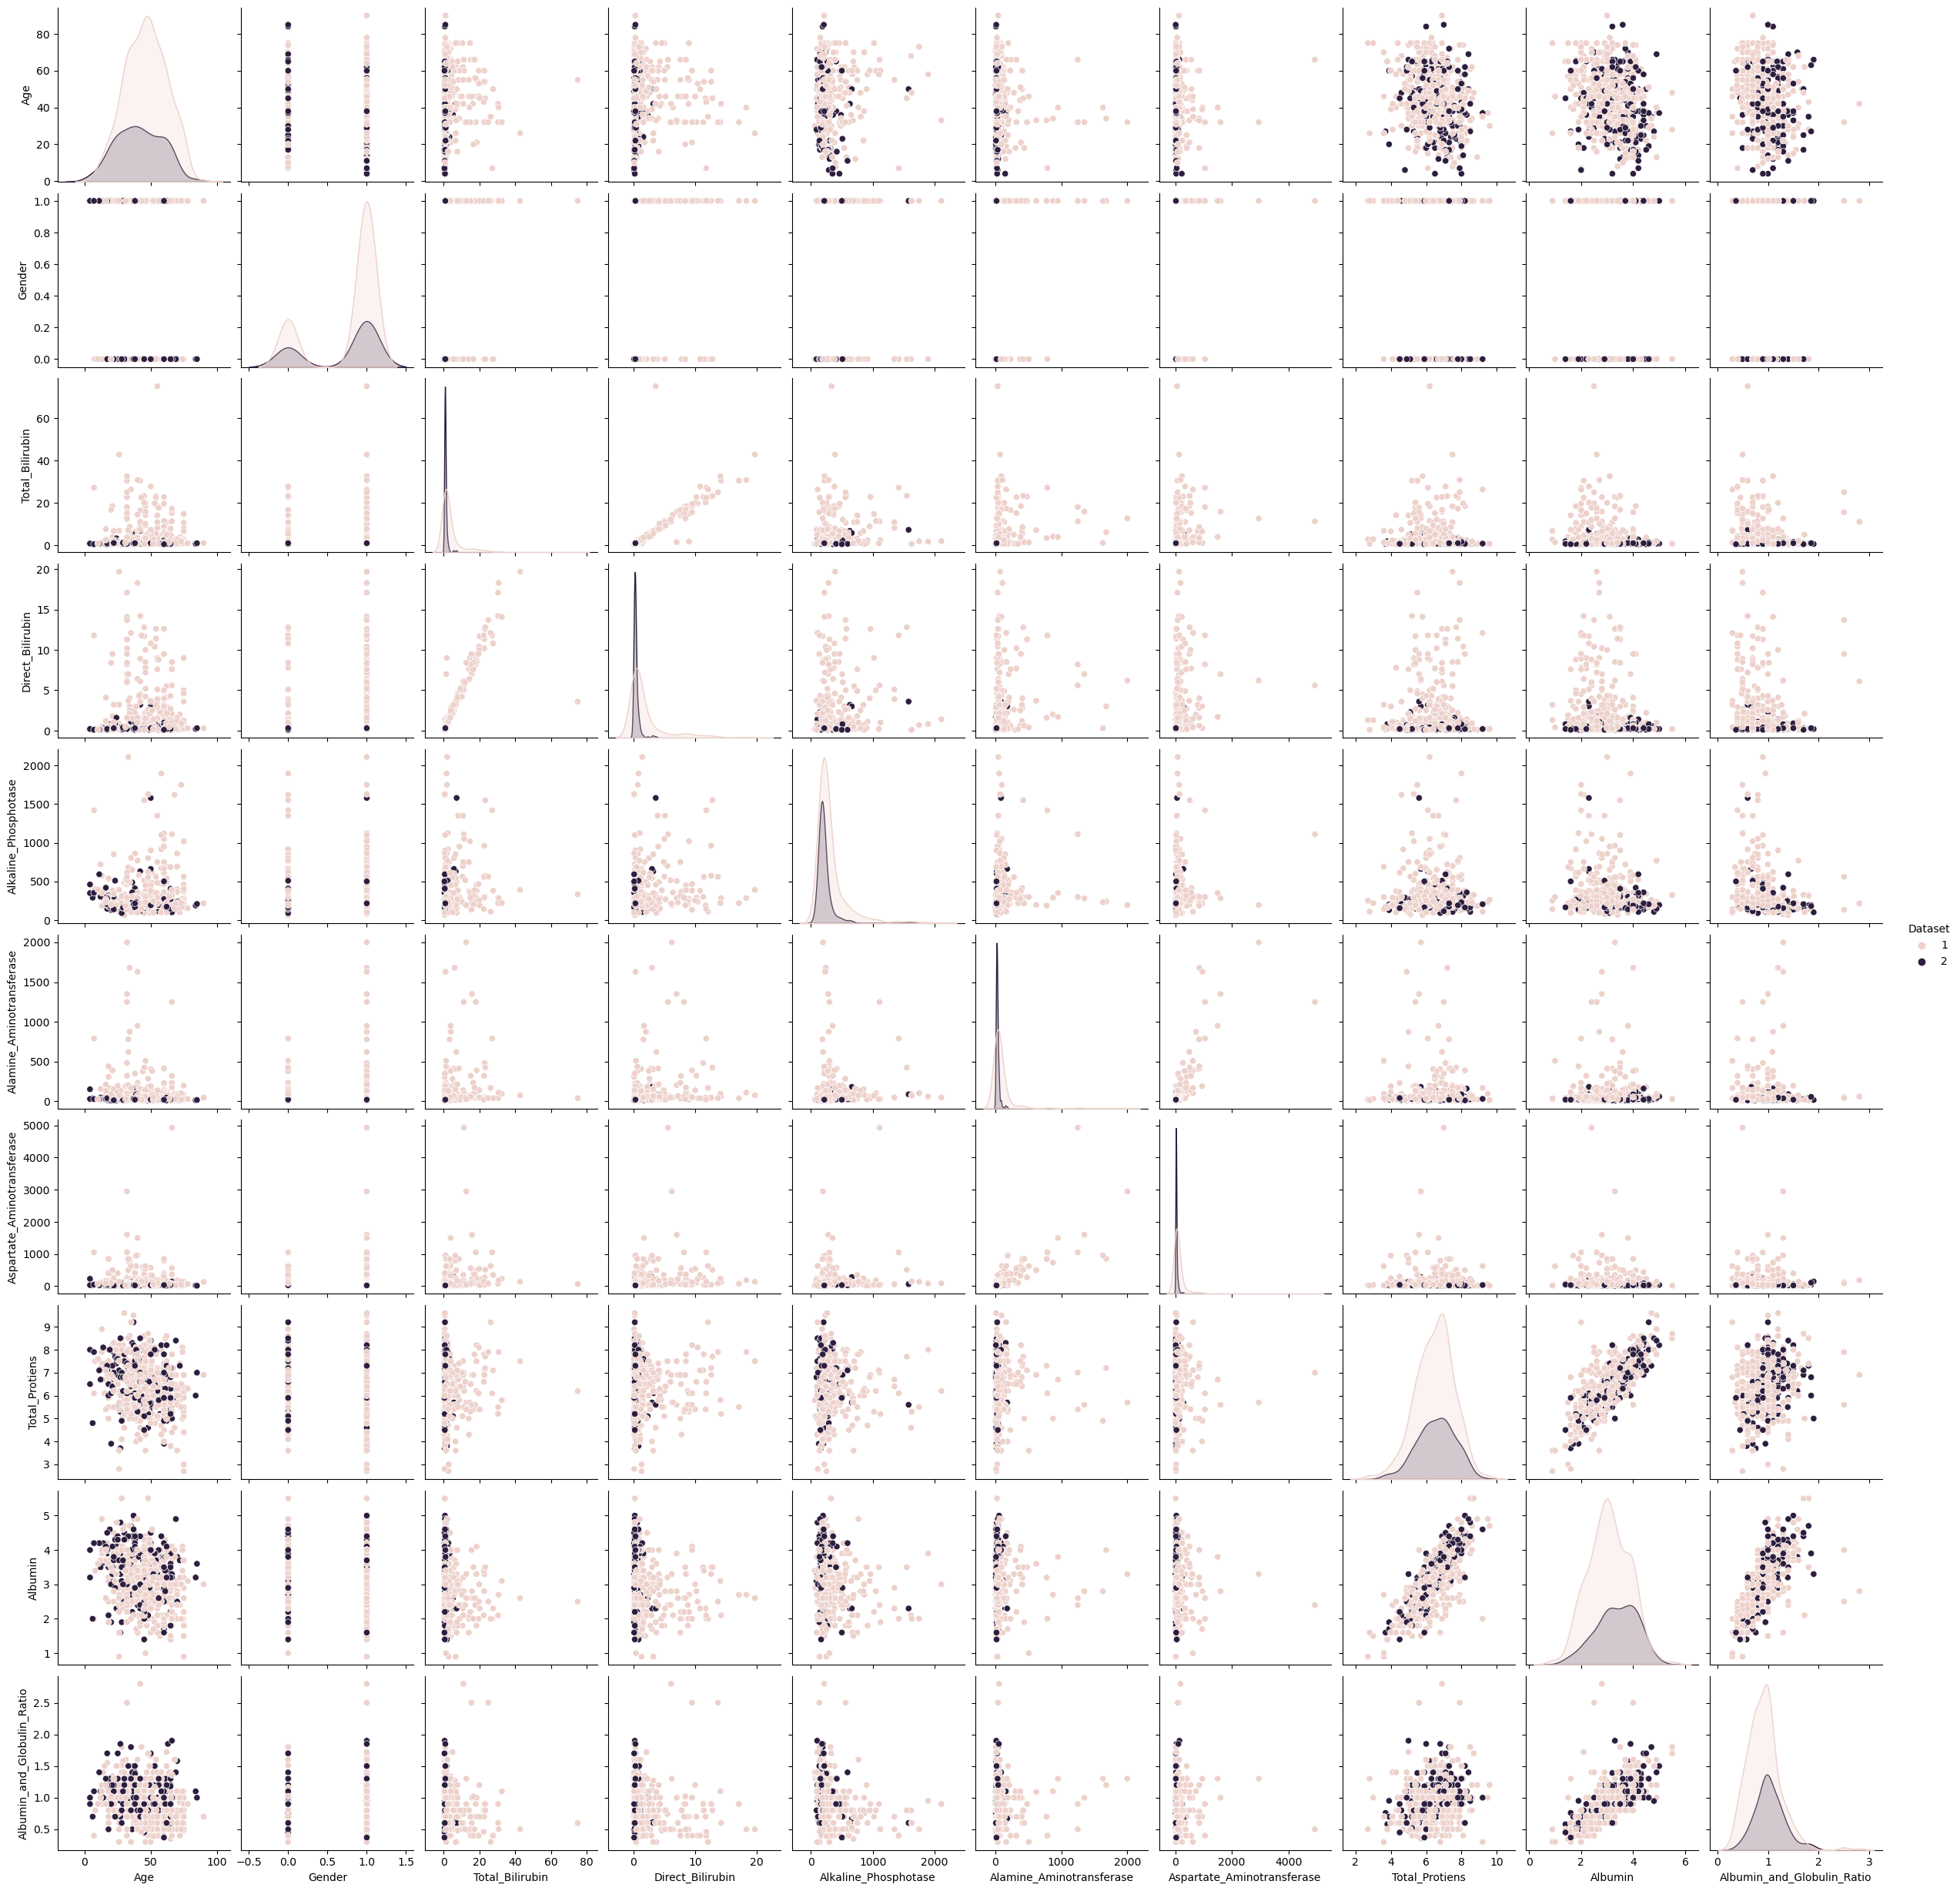

Insight: Shows relationships between features and target variable


In [27]:
sns.pairplot(df, hue='Dataset')
plt.show()

print("Insight: Shows relationships between features and target variable")

In [28]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

print("Insight: Outliers removed to improve model performance")

Original Shape: (570, 11)
After Removing Outliers: (279, 11)
Insight: Outliers removed to improve model performance
